# 따릉이 거치대 수량(Available) 예측 — Weekday SARIMA/ARIMAX Pipeline

## 1. 라이브러리 로드 및 설정

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import jarque_bera, shapiro
from sklearn.metrics import mean_squared_error, mean_absolute_error


plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"


In [3]:
# pip install pmdarima nbformat

## 2. 설정값 및 데이터 로드

In [4]:
# 설정값
DATA_DIR        = Path("../data")   # interpolated_available_YYYYMM.csv
SEASONAL_PERIOD = 24                # 일일 계절 주기 (시간 단위 → S=24)
TEST_DAYS       = 7                 # 마지막 7일을 test set으로 사용
ALPHA           = 0.5               # 비대칭 손실 과소예측 패널티

In [5]:
def load_remains_csvs(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("interpolated_available_*.csv"))
    if not files:
        raise FileNotFoundError(f"interpolated_available_*.csv 파일이 없습니다: {data_dir}")
    parts = [
        pd.read_csv(f, dtype={"DATE": str, "TIME": str,
                               "RENT_ID": str, "AVAILABLE": int})
        for f in files
    ]
    df = pd.concat(parts, ignore_index=True)
    df["RENT_ID"] = df["RENT_ID"].str.zfill(5)
    df["datetime"] = pd.to_datetime(
        df["DATE"] + df["TIME"].str.zfill(2),
        format="%Y%m%d%H"
    )
    df["CNT"] = df["AVAILABLE"]

    return df

df_raw = load_remains_csvs(DATA_DIR)
print(f"전체 데이터: {df_raw.shape}")
print(f"날짜 범위: {df_raw['datetime'].min()} ~ {df_raw['datetime'].max()}")
print(f"정류소 수: {df_raw['RENT_ID'].nunique()}개")
print(f"정류소 목록: {sorted(df_raw['RENT_ID'].unique())}")
df_raw.head()


전체 데이터: (381432, 6)
날짜 범위: 2023-01-01 00:00:00 ~ 2024-12-31 23:00:00
정류소 수: 23개
정류소 목록: ['02111', '02112', '02116', '02122', '02128', '02129', '02130', '02139', '02143', '02148', '02159', '02171', '02172', '02178', '02179', '02185', '02186', '02191', '02198', '02199', '03310', '03311', '03802']


,DATE,TIME,RENT_ID,AVAILABLE,datetime,CNT
0,20230101,0,02111,0,2023-01-01,0
1,20230101,0,02112,5,2023-01-01,5
2,20230101,0,02116,2,2023-01-01,2
3,20230101,0,02122,1,2023-01-01,1
4,20230101,0,02128,5,2023-01-01,5


## 2. 평가 함수 정의

### 평가 지표
| 지표 | 설명 | 비고 |
|------|------|------|
| **RMSE** | 기본 예측 정확도, 큰 오차에 민감 | 주요 지표 |
| **MAE** | 평균 절대 오차, 이상치 영향 적음 | 보조 지표 |
| **Asymmetric RMSE** | 과소예측에 $\alpha$배 패널티 | 조교님 권장 |
| **과소예측 비율** | $\hat{y} < y$ 인 비율 | 거치대 부족 위험도 |

### 비대칭 손실함수
$$L(\hat{y}, y) = \begin{cases} \alpha \cdot (\hat{y} - y)^2 & \text{if } \hat{y} < y \text{ (과소예측)} \\ (\hat{y} - y)^2 & \text{if } \hat{y} \geq y \text{ (과대예측)} \end{cases}$$

In [6]:
def asymmetric_rmse(actual: pd.Series, forecast: pd.Series, alpha: float = 2.0) -> float:
    errors = forecast.values - actual.values
    loss = np.where(errors < 0, alpha * errors**2, errors**2)
    return float(np.sqrt(loss.mean()))


def evaluate_forecast(fitted_model, test: pd.Series,
                      model_name: str = "SARIMA",
                      exog_test: pd.DataFrame = None,
                      alpha: float = 2.0) -> dict:
    if exog_test is not None:
        forecast = fitted_model.forecast(steps=len(test), exog=exog_test)
    else:
        forecast = fitted_model.forecast(steps=len(test))

    forecast  = pd.Series(forecast.values, index=test.index)
    errors    = forecast - test

    rmse      = np.sqrt(mean_squared_error(test, forecast))
    mae       = mean_absolute_error(test, forecast)
    asym      = asymmetric_rmse(test, forecast, alpha=alpha)
    under_rate = (errors < 0).mean() * 100

    print(f"[{model_name}]")
    print(f"  RMSE              : {rmse:.3f}")
    print(f"  MAE               : {mae:.3f}")
    print(f"  Asymmetric RMSE   : {asym:.3f}  (alpha={alpha}, 과소예측 {alpha}배 패널티)")
    print(f"  과소예측 비율      : {under_rate:.1f}%  ← 거치대 부족 위험")

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(test.index, test.values, label="Actual (y)", alpha=0.7)
    axes[0].plot(forecast.index, forecast.values,
                 label=f"Forecast y-hat ({model_name})", linestyle="--", alpha=0.8)
    axes[0].set_title(f"Forecast vs Actual - {model_name}  "
                      f"[RMSE={rmse:.2f} | Asym.RMSE={asym:.2f}]")
    axes[0].legend()

    colors = ["red" if e < 0 else "steelblue" for e in errors]
    axes[1].bar(range(len(errors)), errors.values, color=colors, alpha=0.6, width=1)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title(f"Forecast Error (y-hat - y)  |  "
                      f"Red=Under, Blue=Over  |  Under-pred={under_rate:.1f}%")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        f"Asym.RMSE(α={alpha})": round(asym, 3),
        "과소예측비율(%)": round(under_rate, 1),
    }


## 3. SARIMA 적합 진단 — 02111 / 02112 / 02116

AutoARIMA로 탐색된 최적 차수로 각 정류소 SARIMA 적합 및 예측 평가.

In [7]:
import sys
sys.path.insert(0, str(Path("..").resolve()))
from src.utils import make_series as _make_series

all_results = []

[Station 02111]  ARIMA(2, 0, 2)x(2, 1, 0, 24)
  Train: 2023-01-01 ~ 2024-12-24  (17,376h)
  Test : 2024-12-25 ~ 2024-12-31  (168h)
  [ADF] p=0.0000  → 정상
                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                17376
Model:             SARIMAX(2, 0, 2)x(2, 1, [], 24)   Log Likelihood              -32462.204
Date:                             Sat, 30 May 2026   AIC                          64938.408
Time:                                     18:59:09   BIC                          64992.718
Sample:                                 01-01-2023   HQIC                         64956.302
                                      - 12-24-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

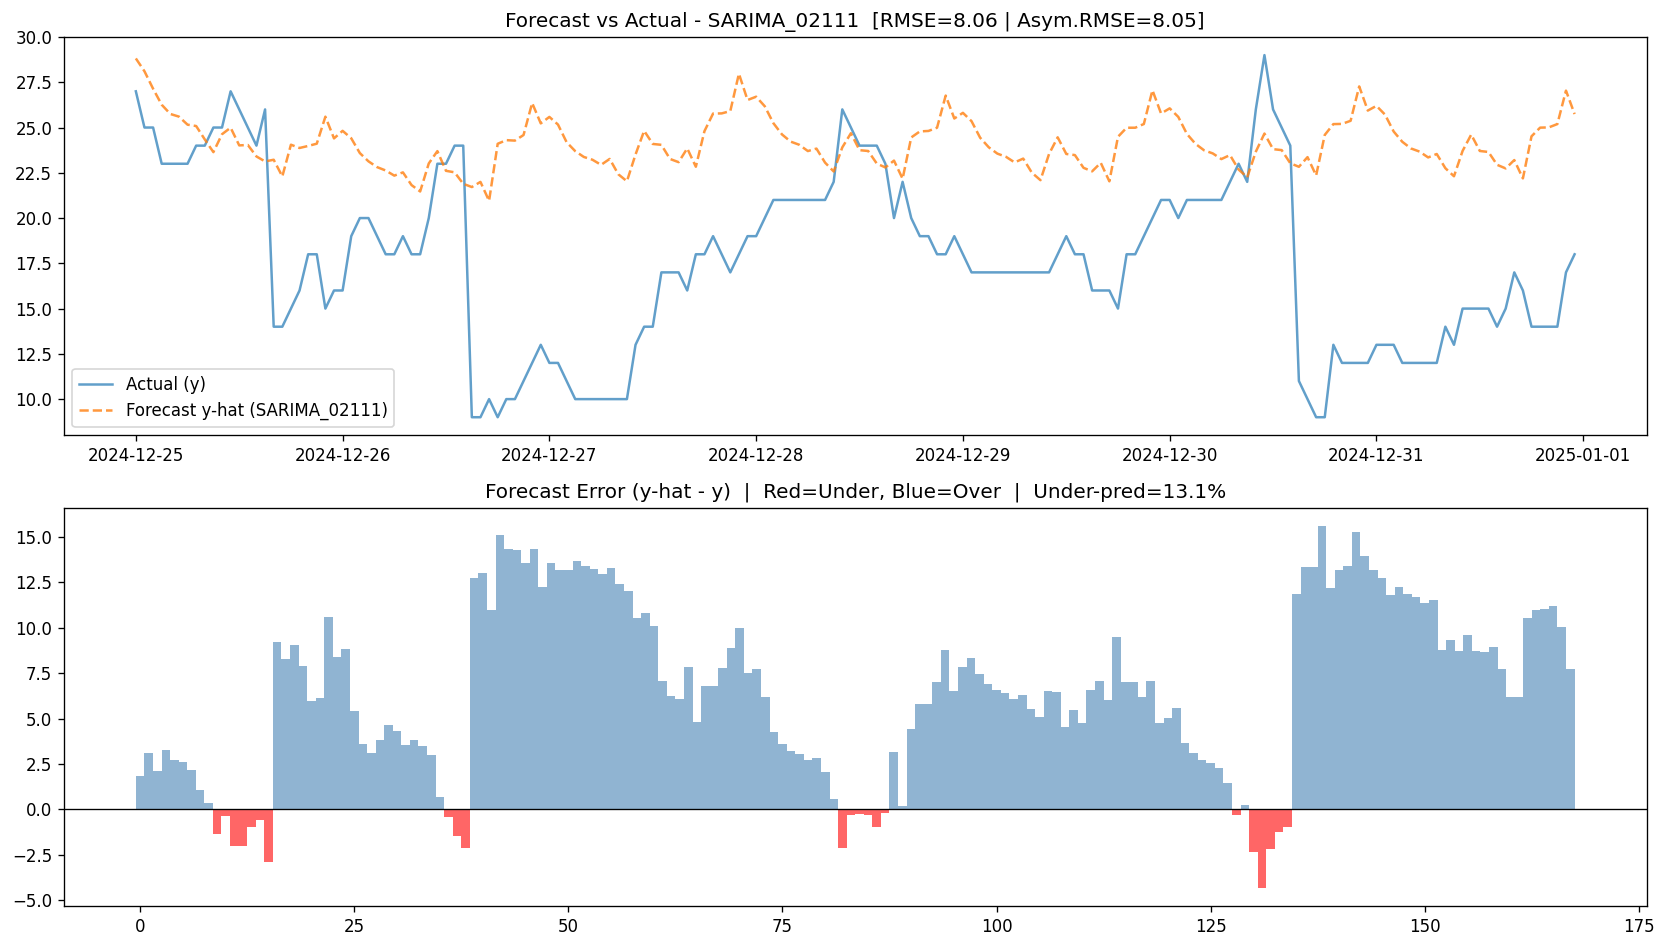

15869

In [8]:
import gc

# ── Station 02111  ARIMA(2,0,2)x(2,1,0,24) ──────────────────────────────────
station_id    = "02111"
order         = (2, 0, 2)
seasonal_order = (2, 1, 0, SEASONAL_PERIOD)

s = _make_series(df_raw, station_id).dropna()
tr, te = s.iloc[:-TEST_DAYS * 24], s.iloc[-TEST_DAYS * 24:]
print(f"[Station {station_id}]  ARIMA{order}x{seasonal_order}")
print(f"  Train: {tr.index[0].date()} ~ {tr.index[-1].date()}  ({len(tr):,}h)")
print(f"  Test : {te.index[0].date()} ~ {te.index[-1].date()}  ({len(te):,}h)")

res = adfuller(tr.dropna(), maxlag=6, autolag="AIC")
print(f"  [ADF] p={res[1]:.4f}  → {'정상' if res[1] < 0.05 else '비정상 → 계절차분 권장'}")

fit_02111 = SARIMAX(tr, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(fit_02111.summary())

perf = evaluate_forecast(fit_02111, te, model_name=f"SARIMA_{station_id}", alpha=ALPHA)
perf["station_id"] = station_id
all_results.append(perf)

try:
    del s
except:
    pass
gc.collect()

[Station 02112]  ARIMA(1, 0, 0)x(2, 1, 0, 24)
  Train: 2023-01-01 ~ 2024-12-24  (17,376h)
  Test : 2024-12-25 ~ 2024-12-31  (168h)
  [ADF] p=0.0000  → 정상
                                     SARIMAX Results                                      
Dep. Variable:                                CNT   No. Observations:                17376
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 24)   Log Likelihood              -33044.871
Date:                            Sat, 30 May 2026   AIC                          66097.742
Time:                                    19:00:16   BIC                          66128.777
Sample:                                01-01-2023   HQIC                         66107.967
                                     - 12-24-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

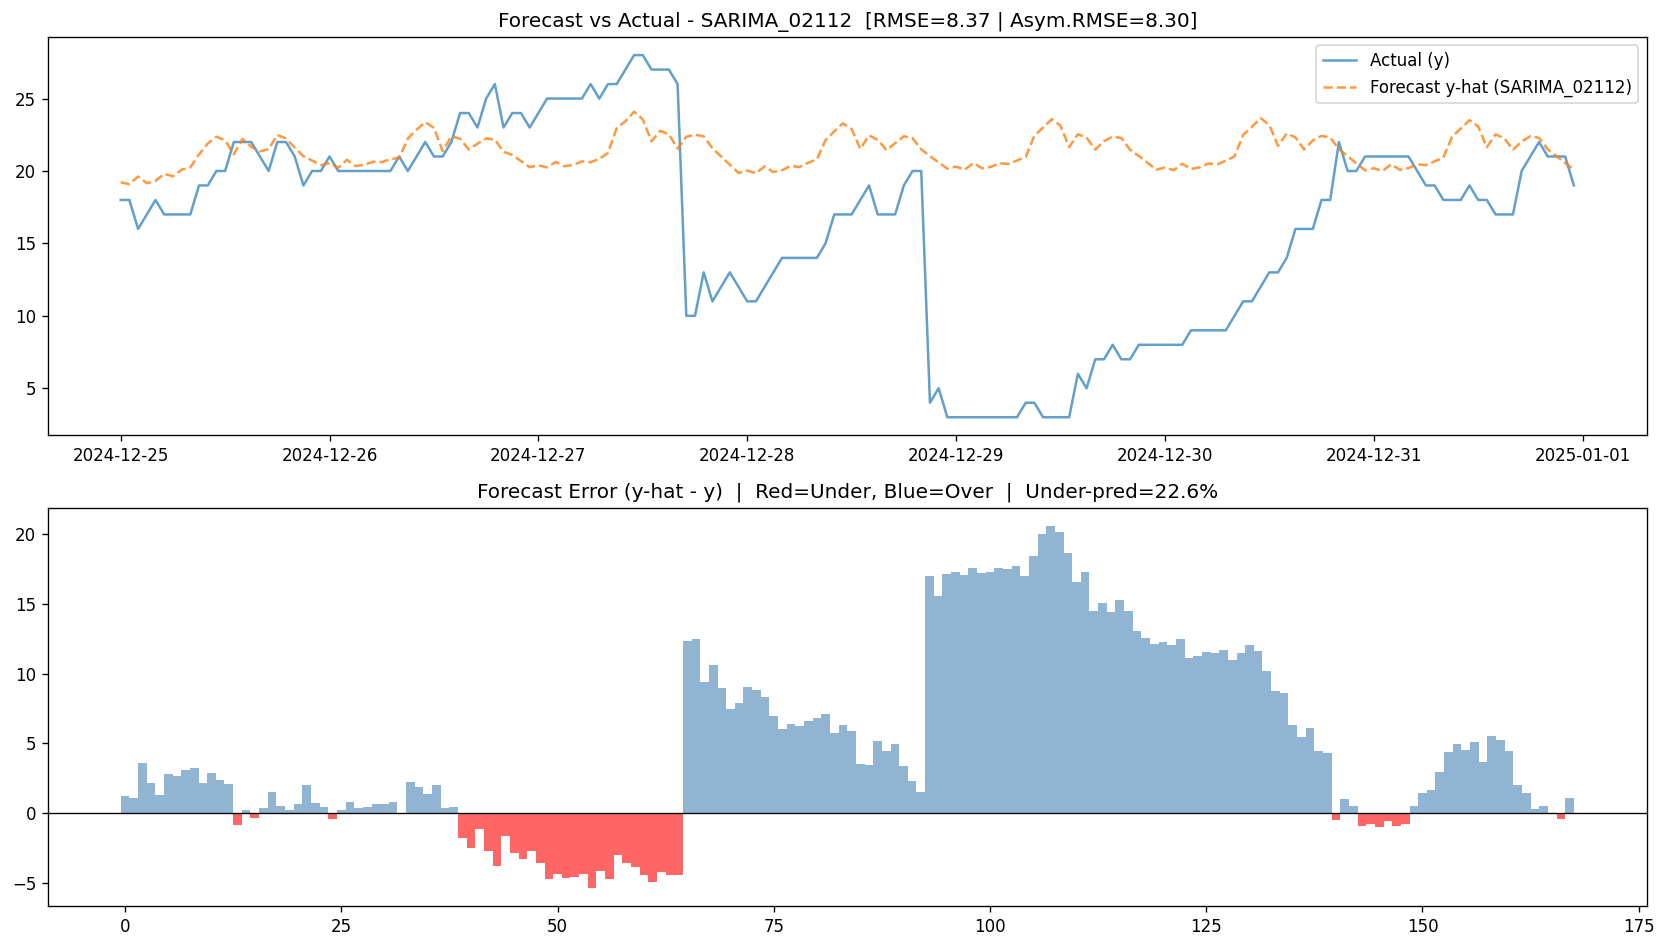

15306

In [9]:
# ── Station 02112  ARIMA(1,0,0)x(2,1,0,24) ──────────────────────────────────
station_id    = "02112"
order         = (1, 0, 0)
seasonal_order = (2, 1, 0, SEASONAL_PERIOD)

s = _make_series(df_raw, station_id).dropna()
tr, te = s.iloc[:-TEST_DAYS * 24], s.iloc[-TEST_DAYS * 24:]
print(f"[Station {station_id}]  ARIMA{order}x{seasonal_order}")
print(f"  Train: {tr.index[0].date()} ~ {tr.index[-1].date()}  ({len(tr):,}h)")
print(f"  Test : {te.index[0].date()} ~ {te.index[-1].date()}  ({len(te):,}h)")

res = adfuller(tr.dropna(), maxlag=6, autolag="AIC")
print(f"  [ADF] p={res[1]:.4f}  → {'정상' if res[1] < 0.05 else '비정상 → 계절차분 권장'}")

fit_02112 = SARIMAX(tr, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(fit_02112.summary())

perf = evaluate_forecast(fit_02112, te, model_name=f"SARIMA_{station_id}", alpha=ALPHA)
perf["station_id"] = station_id
all_results.append(perf)

try:
    del s
except:
    pass
gc.collect()

[Station 02116]  ARIMA(1, 0, 2)x(2, 1, 0, 24)
  Train: 2023-01-01 ~ 2024-12-24  (17,376h)
  Test : 2024-12-25 ~ 2024-12-31  (168h)
  [ADF] p=0.0000  → 정상
                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                17376
Model:             SARIMAX(1, 0, 2)x(2, 1, [], 24)   Log Likelihood              -31586.841
Date:                             Sat, 30 May 2026   AIC                          63185.683
Time:                                     19:01:38   BIC                          63232.234
Sample:                                 01-01-2023   HQIC                         63201.020
                                      - 12-24-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

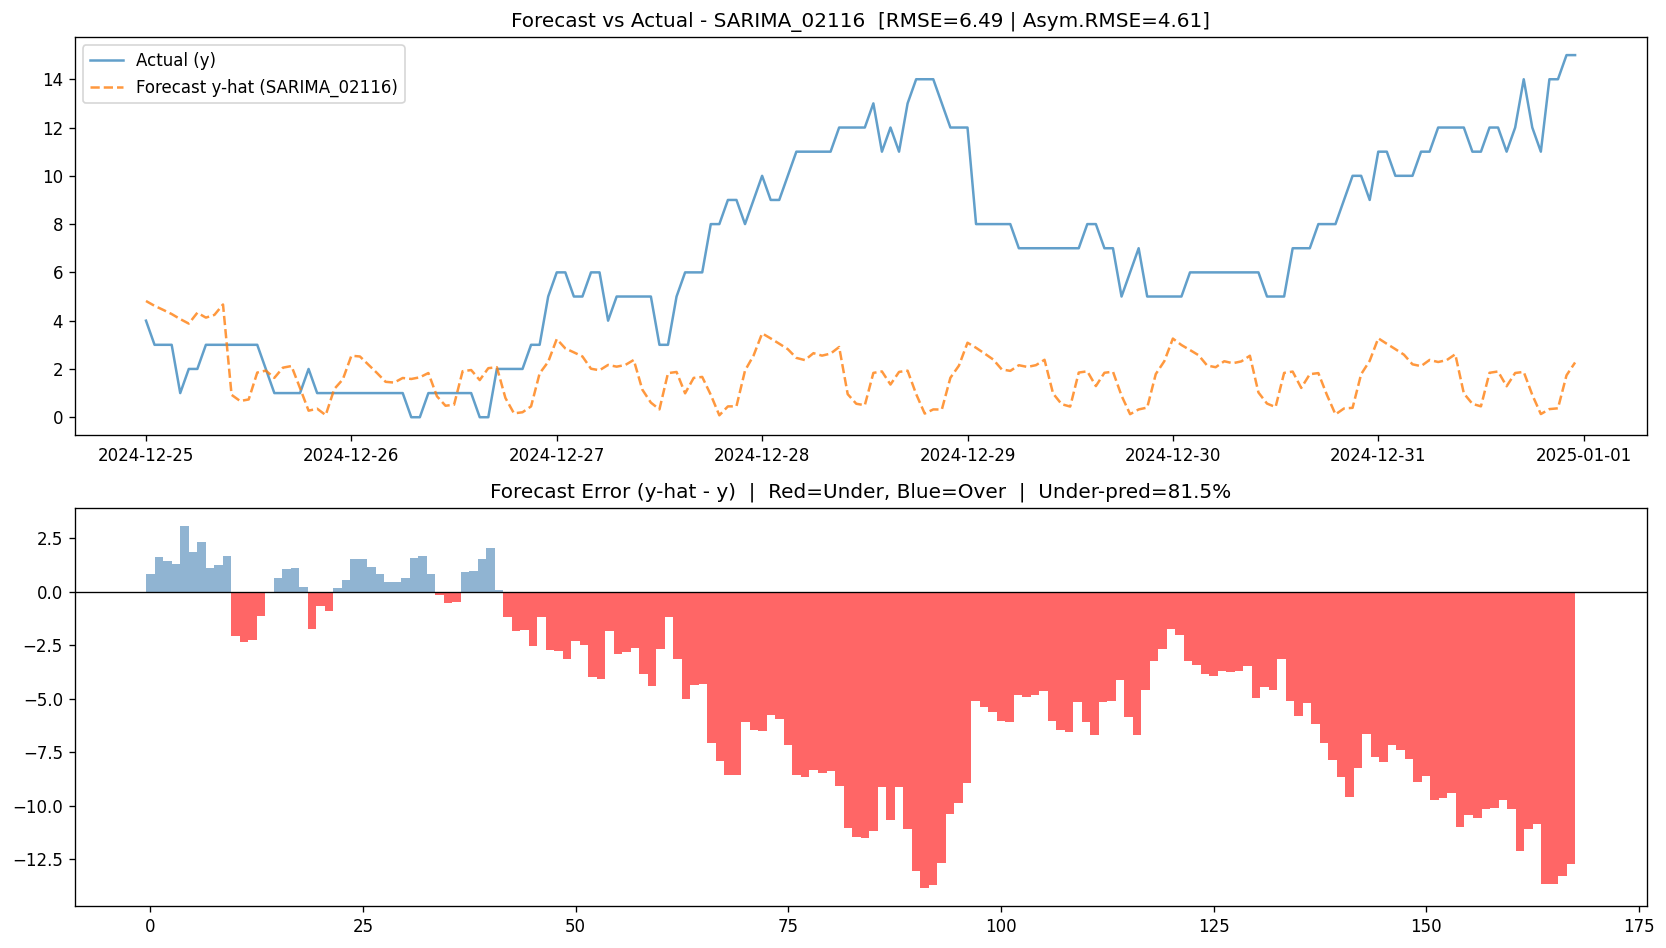

15751

In [10]:
# ── Station 02116  ARIMA(1,0,2)x(2,1,0,24) ──────────────────────────────────
station_id    = "02116"
order         = (1, 0, 2)
seasonal_order = (2, 1, 0, SEASONAL_PERIOD)

s = _make_series(df_raw, station_id).dropna()
tr, te = s.iloc[:-TEST_DAYS * 24], s.iloc[-TEST_DAYS * 24:]
print(f"[Station {station_id}]  ARIMA{order}x{seasonal_order}")
print(f"  Train: {tr.index[0].date()} ~ {tr.index[-1].date()}  ({len(tr):,}h)")
print(f"  Test : {te.index[0].date()} ~ {te.index[-1].date()}  ({len(te):,}h)")

res = adfuller(tr.dropna(), maxlag=6, autolag="AIC")
print(f"  [ADF] p={res[1]:.4f}  → {'정상' if res[1] < 0.05 else '비정상 → 계절차분 권장'}")

fit_02116 = SARIMAX(tr, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(fit_02116.summary())

perf = evaluate_forecast(fit_02116, te, model_name=f"SARIMA_{station_id}", alpha=ALPHA)
perf["station_id"] = station_id
all_results.append(perf)

try:
    del s
except:
    pass
gc.collect()

In [11]:
# ── 전체 비교 요약 ──────────────────────────────────────────────────────────────
print(pd.DataFrame(all_results).set_index("station_id").to_string())

                   model   RMSE    MAE  Asym.RMSE(α=0.5)  과소예측비율(%)
station_id                                                         
02111       SARIMA_02111  8.058  6.833             8.046       13.1
02112       SARIMA_02112  8.375  6.164             8.305       22.6
02116       SARIMA_02116  6.494  5.314             4.610       81.5
